# **Car Price Analysis EDA**

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

## Import libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline
# last line of code generated by Gemini in Project 1 to allow matplotlib plots to be seen

## Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [25]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\world\\Documents\\CI VS Code Projects\\Capstone Projects\\Car-Price-Analysis'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [4]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [5]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\world\\Documents\\CI VS Code Projects\\Capstone Projects\\Car-Price-Analysis'

## Load Cleaned Data

In [26]:
# code changed from Gemini
df = pd.read_csv('data/cleaned data/car_price_cleaned.csv')

df.shape

(205, 27)

In [27]:
# check the first 5 rows to see if it has loaded correctly
df.head()

,car_id,symboling,car_name,fuel_type,aspiration,door_number,body_style,drive_wheel,engine_location,wheel_base,...,fuel_system,bore_ratio,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price,brand
0,1,3,alfa-romero giulia,gas,std,2,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romeo
1,2,3,alfa-romero stelvio,gas,std,2,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romeo
2,3,1,alfa-romero Quadrifoglio,gas,std,2,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romeo
3,4,2,audi 100 ls,gas,std,4,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,audi 100ls,gas,std,4,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


## Outlier Check

We will inspect the distribution of our target variable, `price`, to check for potential outliers. In our summary statistics in the ETL Notebook, prices ranged from $5,118 to $45,400, with a jump from the 75th percentile to the maximum value. We will use a box plot to visualise this distribution and see whether high-end values represent data errors or legitimate luxury vehicles.

AI Usage Note: Generative AI was used for language refinement.

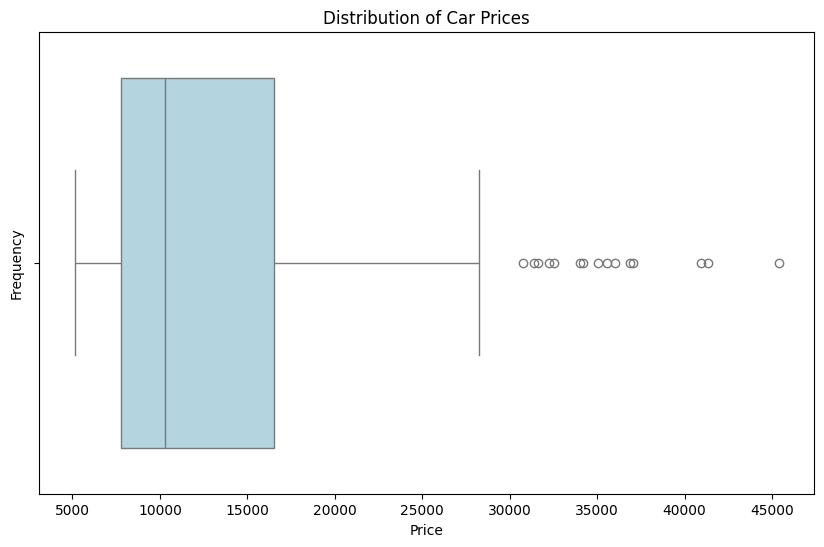

In [28]:
# Gemini and copilot prediction used in this code
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='price', color='lightblue')
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Price Outlier Observations

Threshold: The box plot shows several data points sitting beyond the upper whisker ($Q3 + 1.5 \times \text{IQR}$, around $28,500), which technically marks them as outliers.

Distribution Pattern: Rather than one isolated point, the values above the upper whisker increase gradually across the $30,000 to $45,400 range. This steady spread supports the idea that these are not data entry errors.   

Business Decision: These higher prices represent genuine luxury or high performance cars in the market. As they reflect real-world data, all values will be kept for our hypotheses testing and analyses.

AI Usage Note: Generative AI was used for grammar and language refinement to assist in drafting this summary based on my findings and conclusions.

## Business Hypotheses Considerations

Our hypotheses will focus on factors affecting car price, as this is the target we have identified from the project goals for this dataset in Unit 2. We will later train a machine learning prediction model based on this target. Inspecting our data and looking carefully at the summary statistics for each column gives us a few key features that may relate to car prices.

We can plot a heatmap to see the relationship between price and other numerical columns, then use our findings to guide our hypotheses.



In [29]:
# we will check how many numerical columns are in our dataset
# code from Gemini
df.select_dtypes(include='number').columns

Index(['car_id', 'symboling', 'door_number', 'wheel_base', 'car_length',
       'car_width', 'car_height', 'curb_weight', 'cylinder_number',
       'engine_size', 'bore_ratio', 'stroke', 'compression_ratio',
       'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price'],
      dtype='object')

In [30]:
# we will calculate the correlation matrix to see how the numerical features are correlated with each other and save it in a variable
# we will drop the 'car_id' column
# coded with help from Gemini
corr_matrix = df.select_dtypes(include='number').drop(columns=['car_id']).corr()

<Axes: >

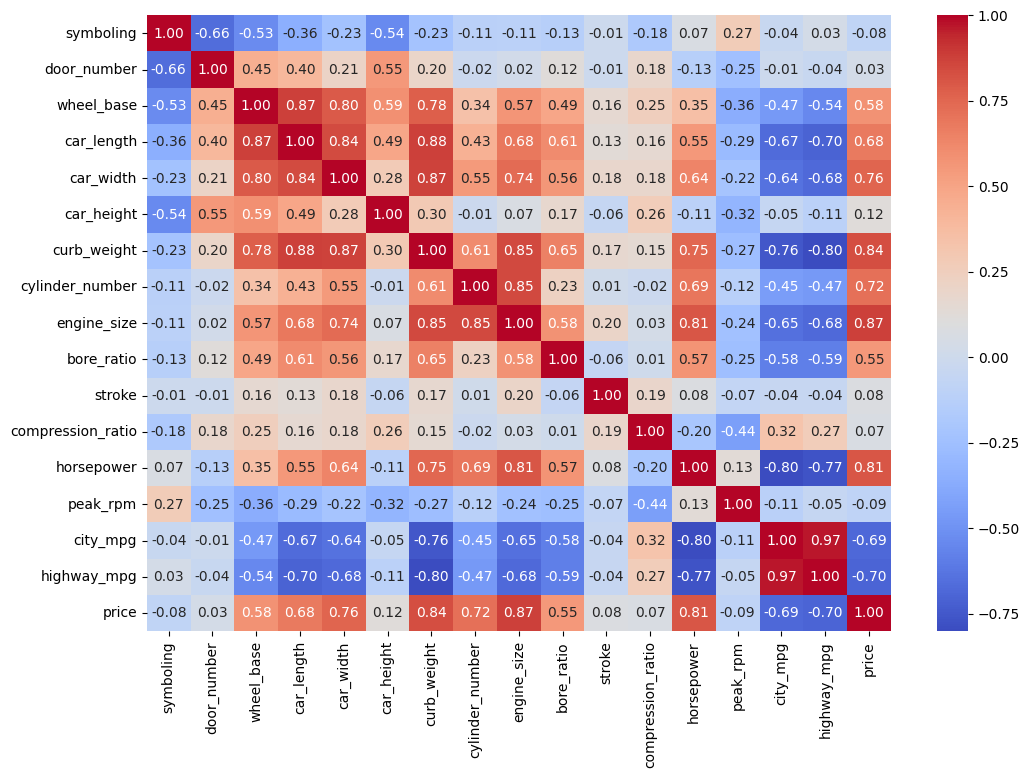

In [31]:
# we will plot a heatmap of the correlations
# Copilot predictions used to generate code
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f") 

The correlation matrix score ranges from 1 to -1. A score of 0 indicates no correlation. Values closer to 1 show a strong positive relationship, while values closer to -1 show a strong inverse relationship. The heatmap reveals that the features most strongly correlated with price are `engine_size`, `curb_weight`, `horsepower`, `car_width`, `cylinder_number`, `highway_mpg`, `city_mpg`, and `car_length`. While most of these have positive correlations with price, `highway_mpg` and `city_mpg` have strong negative correlations. This makes sense as larger engines and heavier cars require more fuel to run, leading to lower MPG. Our hypotheses will focus directly on engine and body specifications rather than tracking MPG separately.
(AI Usage Note: Generative AI was used for grammar and language refinement to assist in drafting this summary based on my findings and conclusions.)

We will look at the categorical columns quickly to see where the greatest differences lie before we finalise our hypotheses. We will do this by creating a variable with all the categorical columns, then looping through them and plotting each column against price.

In [32]:
# save categorical columns to a variable, dropping 'car_name' for cleaner plots
# code generated with help from Gemini
cat_cols = df.select_dtypes(include='object').drop(columns=['car_name']).columns

In [33]:
# check how many columns are categorical (excluding 'car_name')
len(cat_cols)

8

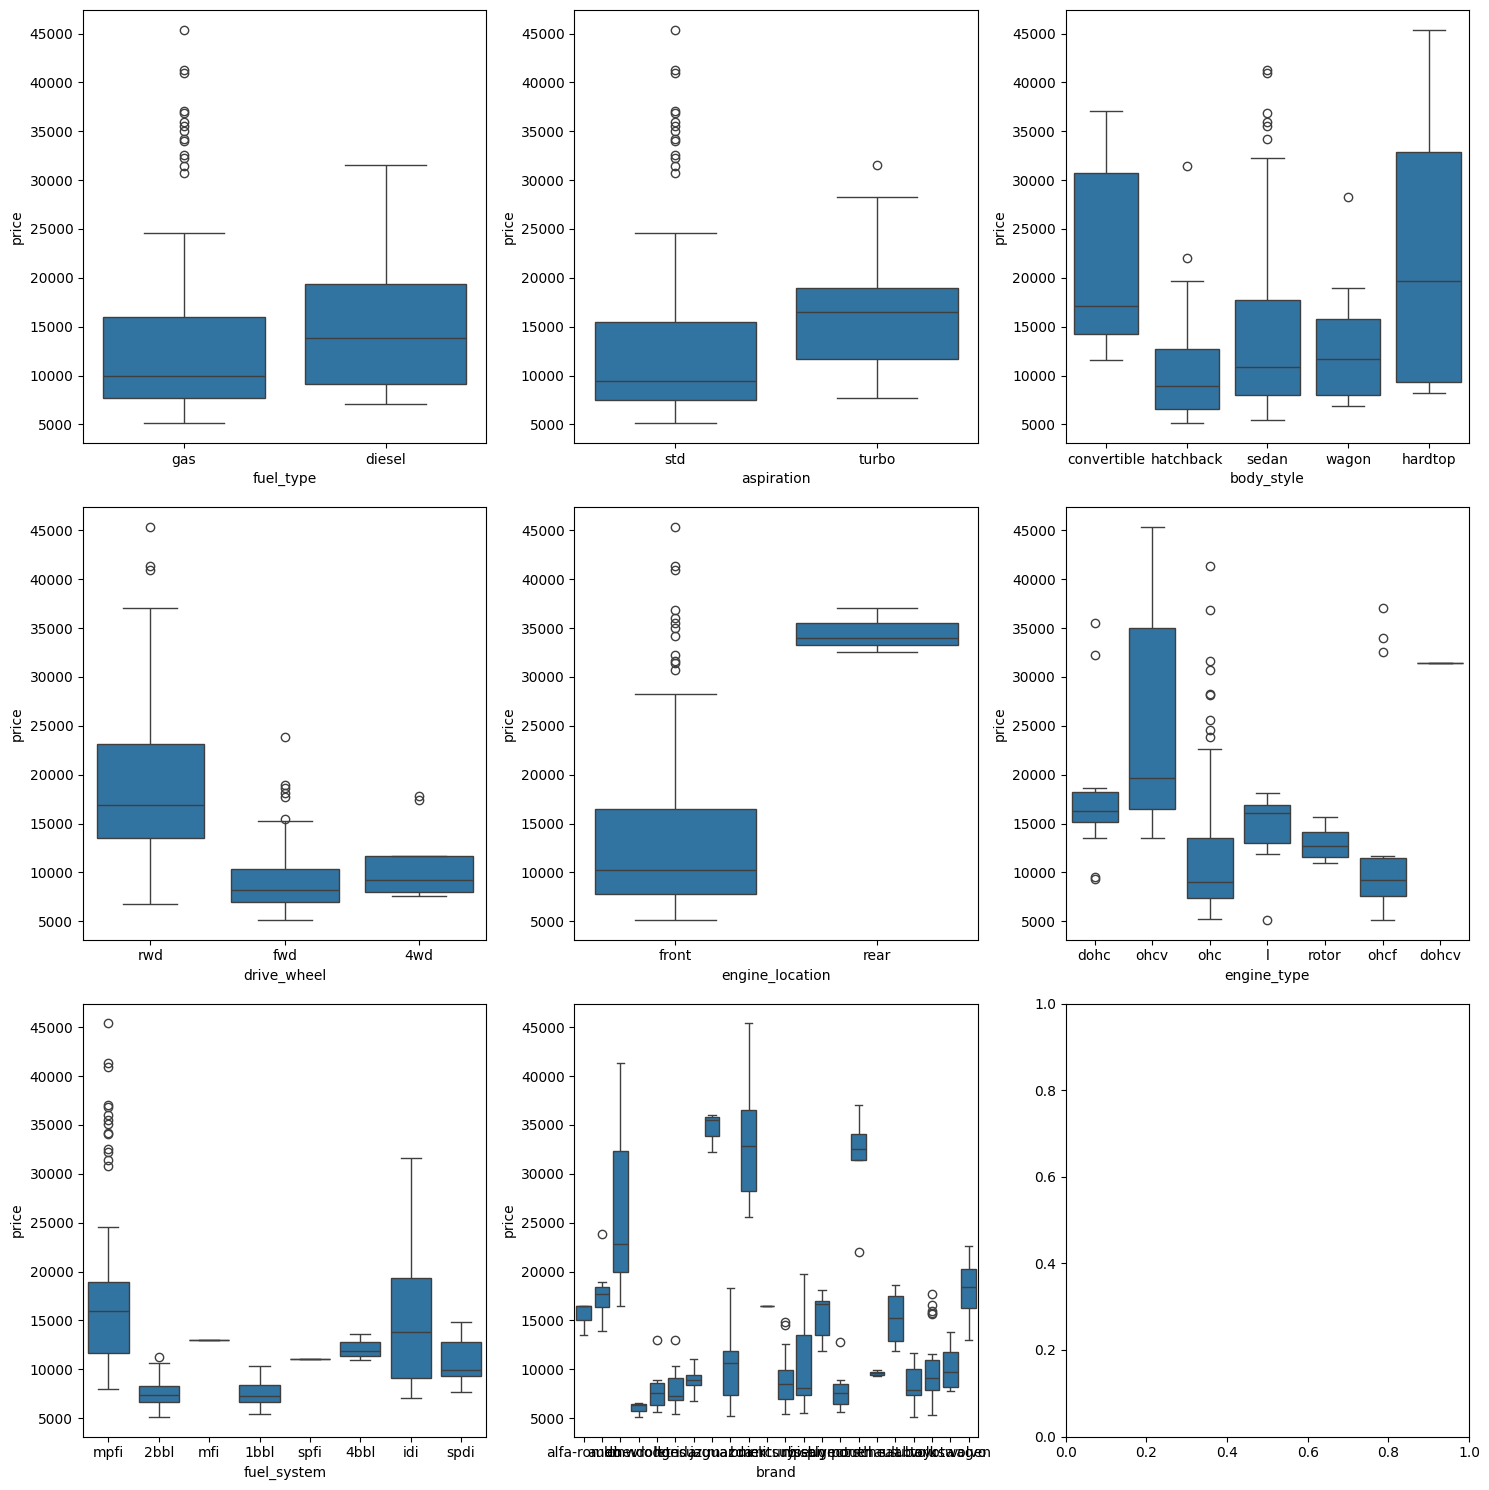

In [34]:
# we will loop through the categorical variables and create bar plots for each one
# code created with Gemini
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
axes = axes.flatten()

for index, col in enumerate(cat_cols):
    sns.boxplot(data=df, x=col, y='price', ax=axes[index])

plt.tight_layout()
plt.show()

We plotted all the categorical features against price to identify what drives price and what we will leave out of our hypotheses.
 
- **What we will exclude from our main hypotheses:** 
  - `fuel_type` and `aspiration`: While turbo engines and diesel cars have a higher median price, standard engines and gas cars span the entire price spectrum with severe luxury outliers, making these features inconsistent for explaining pricing.
  - `engine_location`, `engine_type` and `fuel_system`: These categories suffer from heavy imbalance. For example, only 3 cars in the entire dataset have rear engines, and some fuel systems and engine types appear only once, making them unsuitable for reliable statistical testing.
  - `body_style`: There is overlap between body styles and some categories have much smaller sample sizes than others.
- **What we will consider for our main hypotheses:** 
  - `drive_wheel`: Rear-wheel drive (`rwd`) shows a big price difference compared to `fwd` and there is a large sample size for both. Four-wheel drive (`4wd`) accounts for only 9 vehicles, so it is excluded.
  -  `brand`: There are brands present in our dataset that sit at the top of the price range ($30k+). We will test whether luxury brands have significantly higher prices than budget brands, while separately observing whether those premium cars also carry the larger engines and drive systems identified earlier.

We will form our hypotheses based on engine and size specs, drive-wheel and brand.

AI Note: Generative AI was used to assist in phrasing refinement and structure formatting for these visual insights.





In [36]:
# verify category distributions for features flagged during visual inspection
# code from Gemini
imbalanced_cols = [ 'drive_wheel', 'body_style', 'engine_location', 'engine_type', 'fuel_system']

for col in imbalanced_cols:
    print(f"--- Value Counts: {col} ---")
    print(df[col].value_counts())
    print()

--- Value Counts: drive_wheel ---
drive_wheel
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64

--- Value Counts: body_style ---
body_style
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

--- Value Counts: engine_location ---
engine_location
front    202
rear       3
Name: count, dtype: int64

--- Value Counts: engine_type ---
engine_type
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
dohcv      1
Name: count, dtype: int64

--- Value Counts: fuel_system ---
fuel_system
mpfi    94
2bbl    66
idi     20
1bbl    11
spdi     9
4bbl     3
mfi      1
spfi     1
Name: count, dtype: int64



## Business Hypotheses

**Hypothesis 1 (Engine Specs)**  
Null Hypothesis ($H_0$): There is no correlation between engine size/horsepower and car price.  
Alternative Hypothesis ($H_1$): There is a statistically significant correlation between engine size/horsepower and car price.  

---

**Hypothesis 2 (Car Size & Weight)**  
Null Hypothesis ($H_0$): There is no correlation between curb weight/car length and car price.  
Alternative Hypothesis ($H_1$): There is a statistically significant correlation between curb weight/car length and car price.  

---

**Hypothesis 3 (Drive-Wheel)**  
Null Hypothesis ($H_0$): There is no difference in price between rear-wheel drive and front-wheel drive cars.  
Alternative Hypothesis ($H_1$): There is a statistically significant difference in price between rear-wheel drive and front-wheel drive cars.  

---

**Hypothesis 4 (Brand)**  
Null Hypothesis ($H_0$): There is no difference in price between luxury brands and budget/mainstream brands.  
Alternative Hypothesis ($H_1$): There is a statistically significant difference in price between luxury brands and budget/mainstream brands.  

AI Note: Generative AI was used as a language refinement and markdown tool to assist in drafting these hypotheses.